In [3]:
# IMPORTS

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Modèle SARIMAX
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Métriques
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Affichage
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Imports effectués avec succès.")

Imports effectués avec succès.


In [4]:

# 2. CHARGEMENT DU DATASET


df = pd.read_csv("../data/processed/dataset_final.csv")

print("Dataset chargé avec succès.")
print(f"Nombre de lignes : {len(df):,}")
print(f"Nombre de colonnes : {len(df.columns)}")

Dataset chargé avec succès.
Nombre de lignes : 94,224
Nombre de colonnes : 28


In [1]:

# 3. VÉRIFICATION DES TIMESTAMPS
print("Colonnes temporelles :")
print(df[["timestamp_utc", "timestamp_paris"]].head())

print("\nTypes des colonnes :")
print(df[["timestamp_utc", "timestamp_paris"]].dtypes)

Colonnes temporelles :


NameError: name 'df' is not defined

In [7]:
# Vérifier les premières correspondances UTC / Paris

df[["timestamp_utc", "timestamp_paris"]].head(10)

,timestamp_utc,timestamp_paris
0,2016-01-01 00:00:00+00:00,2016-01-01 01:00:00+01:00
1,2016-01-01 01:00:00+00:00,2016-01-01 02:00:00+01:00
2,2016-01-01 02:00:00+00:00,2016-01-01 03:00:00+01:00
3,2016-01-01 03:00:00+00:00,2016-01-01 04:00:00+01:00
4,2016-01-01 04:00:00+00:00,2016-01-01 05:00:00+01:00
5,2016-01-01 05:00:00+00:00,2016-01-01 06:00:00+01:00
6,2016-01-01 06:00:00+00:00,2016-01-01 07:00:00+01:00
7,2016-01-01 07:00:00+00:00,2016-01-01 08:00:00+01:00
8,2016-01-01 08:00:00+00:00,2016-01-01 09:00:00+01:00
9,2016-01-01 09:00:00+00:00,2016-01-01 10:00:00+01:00


In [9]:
# 4. VARIABLES TEMPORELLES ET CALENDAIRES


colonnes_temps = [
    "timestamp_utc",
    "timestamp_paris",
    "heure",
    "jour_semaine",
    "jour_annee",
    "mois",
    "annee",
    "saison"
]

df[colonnes_temps].head(10)

,timestamp_utc,timestamp_paris,heure,jour_semaine,jour_annee,mois,annee,saison
0,2016-01-01 00:00:00+00:00,2016-01-01 01:00:00+01:00,1,4,1,1,2016,Hiver
1,2016-01-01 01:00:00+00:00,2016-01-01 02:00:00+01:00,2,4,1,1,2016,Hiver
2,2016-01-01 02:00:00+00:00,2016-01-01 03:00:00+01:00,3,4,1,1,2016,Hiver
3,2016-01-01 03:00:00+00:00,2016-01-01 04:00:00+01:00,4,4,1,1,2016,Hiver
4,2016-01-01 04:00:00+00:00,2016-01-01 05:00:00+01:00,5,4,1,1,2016,Hiver
5,2016-01-01 05:00:00+00:00,2016-01-01 06:00:00+01:00,6,4,1,1,2016,Hiver
6,2016-01-01 06:00:00+00:00,2016-01-01 07:00:00+01:00,7,4,1,1,2016,Hiver
7,2016-01-01 07:00:00+00:00,2016-01-01 08:00:00+01:00,8,4,1,1,2016,Hiver
8,2016-01-01 08:00:00+00:00,2016-01-01 09:00:00+01:00,9,4,1,1,2016,Hiver
9,2016-01-01 09:00:00+00:00,2016-01-01 10:00:00+01:00,10,4,1,1,2016,Hiver


In [11]:
print("Valeurs uniques de 'heure' :")
print(sorted(df["heure"].dropna().unique()))

print("\nValeurs uniques de 'jour_semaine' :")
print(sorted(df["jour_semaine"].dropna().unique()))

print("\nValeurs uniques de 'saison' :")
print(df["saison"].dropna().unique())


Valeurs uniques de 'heure' :
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]

Valeurs uniques de 'jour_semaine' :
[np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]

Valeurs uniques de 'saison' :
['Hiver' 'Printemps' 'Été' 'Automne']


In [14]:
# 5. VÉRIFICATION : HEURE BASÉE SUR UTC

# On convertit explicitement timestamp_utc en datetime
df["timestamp_utc"] = pd.to_datetime(df["timestamp_utc"], utc=True)

# Heure calculée directement depuis timestamp_utc
heure_utc_calculee = df["timestamp_utc"].dt.hour

# Comparaison avec la colonne existante
erreurs_heure = (df["heure"] != heure_utc_calculee).sum()

print(f"Nombre de lignes où 'heure' ≠ heure UTC : {erreurs_heure}")
print(f"Nombre total de lignes : {len(df)}")

Nombre de lignes où 'heure' ≠ heure UTC : 94224
Nombre total de lignes : 94224


In [16]:
 
# COMPARAISON UTC / PARIS

comparaison = df[
    ["timestamp_utc", "timestamp_paris", "heure", "jour_semaine", "mois", "saison"]
].head(10)

comparaison

,timestamp_utc,timestamp_paris,heure,jour_semaine,mois,saison
0,2016-01-01 00:00:00+00:00,2016-01-01 01:00:00+01:00,1,4,1,Hiver
1,2016-01-01 01:00:00+00:00,2016-01-01 02:00:00+01:00,2,4,1,Hiver
2,2016-01-01 02:00:00+00:00,2016-01-01 03:00:00+01:00,3,4,1,Hiver
3,2016-01-01 03:00:00+00:00,2016-01-01 04:00:00+01:00,4,4,1,Hiver
4,2016-01-01 04:00:00+00:00,2016-01-01 05:00:00+01:00,5,4,1,Hiver
5,2016-01-01 05:00:00+00:00,2016-01-01 06:00:00+01:00,6,4,1,Hiver
6,2016-01-01 06:00:00+00:00,2016-01-01 07:00:00+01:00,7,4,1,Hiver
7,2016-01-01 07:00:00+00:00,2016-01-01 08:00:00+01:00,8,4,1,Hiver
8,2016-01-01 08:00:00+00:00,2016-01-01 09:00:00+01:00,9,4,1,Hiver
9,2016-01-01 09:00:00+00:00,2016-01-01 10:00:00+01:00,10,4,1,Hiver


In [18]:
# Vérification de l'heure Paris
heure_paris_calculee = df["timestamp_paris"].str.extract(r"(\d{2}):\d{2}").astype(int)[0]

print(
    "Nombre de lignes où 'heure' correspond à l'heure Paris :",
    (df["heure"] == heure_paris_calculee).sum()
)

Nombre de lignes où 'heure' correspond à l'heure Paris : 94224


In [20]:
# 7. VARIABLES TEMPORELLES BASÉES SUR UTC
df["heure_utc"] = df["timestamp_utc"].dt.hour
df["jour_semaine_utc"] = df["timestamp_utc"].dt.dayofweek
df["jour_annee_utc"] = df["timestamp_utc"].dt.dayofyear
df["mois_utc"] = df["timestamp_utc"].dt.month
df["annee_utc"] = df["timestamp_utc"].dt.year

df[
    [
        "timestamp_utc",
        "timestamp_paris",
        "heure",
        "heure_utc",
        "jour_semaine",
        "jour_semaine_utc",
        "mois",
        "mois_utc"
    ]
].head(10)

,timestamp_utc,timestamp_paris,heure,heure_utc,jour_semaine,jour_semaine_utc,mois,mois_utc
0,2016-01-01 00:00:00+00:00,2016-01-01 01:00:00+01:00,1,0,4,4,1,1
1,2016-01-01 01:00:00+00:00,2016-01-01 02:00:00+01:00,2,1,4,4,1,1
2,2016-01-01 02:00:00+00:00,2016-01-01 03:00:00+01:00,3,2,4,4,1,1
3,2016-01-01 03:00:00+00:00,2016-01-01 04:00:00+01:00,4,3,4,4,1,1
4,2016-01-01 04:00:00+00:00,2016-01-01 05:00:00+01:00,5,4,4,4,1,1
5,2016-01-01 05:00:00+00:00,2016-01-01 06:00:00+01:00,6,5,4,4,1,1
6,2016-01-01 06:00:00+00:00,2016-01-01 07:00:00+01:00,7,6,4,4,1,1
7,2016-01-01 07:00:00+00:00,2016-01-01 08:00:00+01:00,8,7,4,4,1,1
8,2016-01-01 08:00:00+00:00,2016-01-01 09:00:00+01:00,9,8,4,4,1,1
9,2016-01-01 09:00:00+00:00,2016-01-01 10:00:00+01:00,10,9,4,4,1,1


In [21]:
# Weekend : samedi (5) ou dimanche (6)
df["weekend_utc"] = df["jour_semaine_utc"].isin([5, 6])

# Saison basée sur le mois UTC
def definir_saison_utc(mois):
    if mois in [12, 1, 2]:
        return "Hiver"
    elif mois in [3, 4, 5]:
        return "Printemps"
    elif mois in [6, 7, 8]:
        return "Été"
    else:
        return "Automne"

df["saison_utc"] = df["mois_utc"].map(definir_saison_utc)

# Vérification
df[
    [
        "timestamp_utc",
        "heure_utc",
        "jour_semaine_utc",
        "weekend_utc",
        "mois_utc",
        "saison_utc"
    ]
].head(10)

,timestamp_utc,heure_utc,jour_semaine_utc,weekend_utc,mois_utc,saison_utc
0,2016-01-01 00:00:00+00:00,0,4,False,1,Hiver
1,2016-01-01 01:00:00+00:00,1,4,False,1,Hiver
2,2016-01-01 02:00:00+00:00,2,4,False,1,Hiver
3,2016-01-01 03:00:00+00:00,3,4,False,1,Hiver
4,2016-01-01 04:00:00+00:00,4,4,False,1,Hiver
5,2016-01-01 05:00:00+00:00,5,4,False,1,Hiver
6,2016-01-01 06:00:00+00:00,6,4,False,1,Hiver
7,2016-01-01 07:00:00+00:00,7,4,False,1,Hiver
8,2016-01-01 08:00:00+00:00,8,4,False,1,Hiver
9,2016-01-01 09:00:00+00:00,9,4,False,1,Hiver


In [23]:
# 9. VÉRIFICATION DES VARIABLES FÉRIÉS / VACANCES
print("Valeurs de 'ferie' :")
print(df["ferie"].value_counts(dropna=False))

print("\nValeurs de 'vacances' :")
print(df["vacances"].value_counts(dropna=False))

Valeurs de 'ferie' :
ferie
False    91393
True      2831
Name: count, dtype: int64

Valeurs de 'vacances' :
vacances
0    54663
3    25473
1     7080
2     7008
Name: count, dtype: int64


In [24]:
df[
    [
        "timestamp_utc",
        "timestamp_paris",
        "ferie",
        "vacances"
    ]
].head(20)

,timestamp_utc,timestamp_paris,ferie,vacances
0,2016-01-01 00:00:00+00:00,2016-01-01 01:00:00+01:00,True,3
1,2016-01-01 01:00:00+00:00,2016-01-01 02:00:00+01:00,True,3
2,2016-01-01 02:00:00+00:00,2016-01-01 03:00:00+01:00,True,3
3,2016-01-01 03:00:00+00:00,2016-01-01 04:00:00+01:00,True,3
4,2016-01-01 04:00:00+00:00,2016-01-01 05:00:00+01:00,True,3
5,2016-01-01 05:00:00+00:00,2016-01-01 06:00:00+01:00,True,3
6,2016-01-01 06:00:00+00:00,2016-01-01 07:00:00+01:00,True,3
7,2016-01-01 07:00:00+00:00,2016-01-01 08:00:00+01:00,True,3
8,2016-01-01 08:00:00+00:00,2016-01-01 09:00:00+01:00,True,3
9,2016-01-01 09:00:00+00:00,2016-01-01 10:00:00+01:00,True,3


In [25]:
# 10. VÉRIFICATION DES VARIABLES UTC

print("Heure UTC :", sorted(df["heure_utc"].unique()))
print("Jour semaine UTC :", sorted(df["jour_semaine_utc"].unique()))
print("Mois UTC :", sorted(df["mois_utc"].unique()))
print("Années UTC :", sorted(df["annee_utc"].unique()))
print("Saisons UTC :", df["saison_utc"].unique())
print("Weekend UTC :", df["weekend_utc"].unique())

Heure UTC : [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16), np.int32(17), np.int32(18), np.int32(19), np.int32(20), np.int32(21), np.int32(22), np.int32(23)]
Jour semaine UTC : [np.int32(0), np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]
Mois UTC : [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
Années UTC : [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024), np.int32(2025), np.int32(2026)]
Saisons UTC : ['Hiver' 'Printemps' 'Été' 'Automne']
Weekend UTC : [False  True]


In [27]:
# 11. CONTINUITÉ TEMPORELLE EN UTC
# Trier par timestamp UTC
df = df.sort_values("timestamp_utc").reset_index(drop=True)

# Calcul de l'écart entre deux observations
ecarts = df["timestamp_utc"].diff()

print("Écarts entre observations :")
print(ecarts.value_counts().head(10))

Écarts entre observations :
timestamp_utc
0 days 01:00:00    94223
Name: count, dtype: int64


In [28]:
ecarts_anormaux = df.loc[
    (ecarts.notna()) & (ecarts != pd.Timedelta(hours=1)),
    ["timestamp_utc", "timestamp_paris"]
].copy()

print(f"Nombre d'écarts anormaux : {len(ecarts_anormaux)}")

ecarts_anormaux.head(20)

Nombre d'écarts anormaux : 0


,timestamp_utc,timestamp_paris


In [29]:
# 12. VÉRIFICATION DES DOUBLONS TEMPORELS
doublons_utc = df["timestamp_utc"].duplicated().sum()

print(f"Nombre de timestamps UTC en doublon : {doublons_utc}")

Nombre de timestamps UTC en doublon : 0


In [30]:
# 13. VÉRIFICATION DE LA VARIABLE CIBLE
print("Type de la consommation :")
print(df["consommation_mw"].dtype)

print("\nValeurs manquantes :")
print(df["consommation_mw"].isna().sum())

print("\nStatistiques de la consommation :")
print(df["consommation_mw"].describe())

Type de la consommation :
float64

Valeurs manquantes :
0

Statistiques de la consommation :
count    94224.000000
mean     52158.201138
std      11400.166005
min      29364.500000
25%      43609.375000
50%      50312.000000
75%      59694.125000
max      96129.500000
Name: consommation_mw, dtype: float64


In [32]:
# 14. PRÉPARATION DE LA SÉRIE TEMPORELLE
# On utilise timestamp_utc comme index du modèle
df_model = df.set_index("timestamp_utc").copy()

# Vérification
print("Index temporel :", df_model.index.name)
print("Nombre d'observations :", len(df_model))

df_model[["consommation_mw"]].head()

Index temporel : timestamp_utc
Nombre d'observations : 94224


,consommation_mw
timestamp_utc,
2016-01-01 00:00:00+00:00,56569.0
2016-01-01 01:00:00+00:00,55506.5
2016-01-01 02:00:00+00:00,52404.0
2016-01-01 03:00:00+00:00,49776.0
2016-01-01 04:00:00+00:00,48761.0


In [34]:
# 15. VÉRIFICATION DE L'INDEX TEMPOREL

print("Index trié :", df_model.index.is_monotonic_increasing)
print("Index unique :", df_model.index.is_unique)

print("\nPremière date :", df_model.index.min())
print("Dernière date :", df_model.index.max())

Index trié : True
Index unique : True

Première date : 2016-01-01 00:00:00+00:00
Dernière date : 2026-09-30 23:00:00+00:00


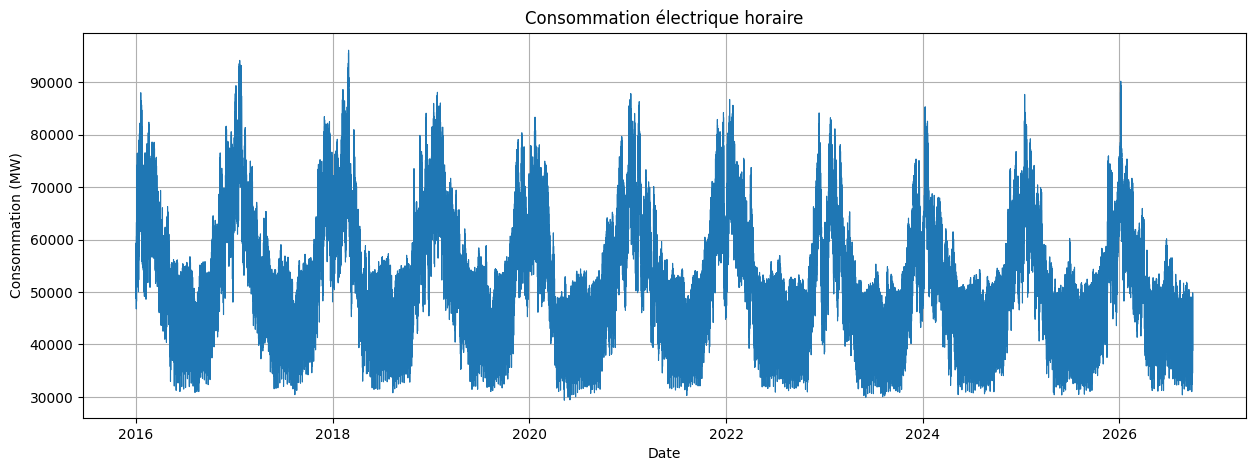

In [37]:
# 16. VISUALISATION DE LA CONSOMMATION
plt.figure(figsize=(15, 5))

plt.plot(
    df_model.index,
    df_model["consommation_mw"],
    linewidth=0.8
)

plt.title("Consommation électrique horaire")
plt.xlabel("Date")
plt.ylabel("Consommation (MW)")
plt.grid(True)

plt.show()


In [ ]:
# 16. CRÉATION DE LA CIBLE À J+1
df_model["consommation_j1"] = df_model["consommation_mw"].shift(-24)

# Affichage de quelques lignes
df_model[
    ["consommation_mw", "consommation_j1"]
].head(30)  

,consommation_mw,consommation_j1
timestamp_utc,,
2016-01-01 00:00:00+00:00,56569.0,52481.0
2016-01-01 01:00:00+00:00,55506.5,51202.5
2016-01-01 02:00:00+00:00,52404.0,48489.5
2016-01-01 03:00:00+00:00,49776.0,46772.0
2016-01-01 04:00:00+00:00,48761.0,46914.0
2016-01-01 05:00:00+00:00,48979.5,48281.0
2016-01-01 06:00:00+00:00,49223.5,49961.0
2016-01-01 07:00:00+00:00,49304.5,51916.5
2016-01-01 08:00:00+00:00,49295.0,53774.5


In [40]:
# 17. VÉRIFICATION DE LA CIBLE J+1
verification = df_model[
    ["consommation_mw", "consommation_j1"]
].copy()

# Pour quelques lignes, afficher aussi le timestamp de la cible
verification["timestamp_cible"] = (
    verification.index + pd.Timedelta(hours=24)
)

verification.head(10)

,consommation_mw,consommation_j1,timestamp_cible
timestamp_utc,,,
2016-01-01 00:00:00+00:00,56569.0,52481.0,2016-01-02 00:00:00+00:00
2016-01-01 01:00:00+00:00,55506.5,51202.5,2016-01-02 01:00:00+00:00
2016-01-01 02:00:00+00:00,52404.0,48489.5,2016-01-02 02:00:00+00:00
2016-01-01 03:00:00+00:00,49776.0,46772.0,2016-01-02 03:00:00+00:00
2016-01-01 04:00:00+00:00,48761.0,46914.0,2016-01-02 04:00:00+00:00
2016-01-01 05:00:00+00:00,48979.5,48281.0,2016-01-02 05:00:00+00:00
2016-01-01 06:00:00+00:00,49223.5,49961.0,2016-01-02 06:00:00+00:00
2016-01-01 07:00:00+00:00,49304.5,51916.5,2016-01-02 07:00:00+00:00
2016-01-01 08:00:00+00:00,49295.0,53774.5,2016-01-02 08:00:00+00:00


In [42]:
# 18. VÉRIFICATION CONCRÈTE DU DÉCALAGE J+1
date_test = "2025-01-15 14:00:00+00:00"

print("Date J :", date_test)
print(
    "Consommation à J :",
    df_model.loc[date_test, "consommation_mw"]
)

date_j1 = pd.Timestamp(date_test) + pd.Timedelta(hours=24)

print("\nDate J+1 :", date_j1)
print(
    "Consommation réelle à J+1 :",
    df_model.loc[date_j1, "consommation_mw"]
)

print(
    "\nValeur enregistrée dans consommation_j1 :",
    df_model.loc[date_test, "consommation_j1"]
)

Date J : 2025-01-15 14:00:00+00:00
Consommation à J : 76032.0

Date J+1 : 2025-01-16 14:00:00+00:00
Consommation réelle à J+1 : 72958.0

Valeur enregistrée dans consommation_j1 : 72958.0


In [43]:
# 19. BENCHMARK : CONSOMMATION DE LA VEILLE
# 19. BENCHMARK : CONSOMMATION DE LA VEILLE


df_model["prediction_j1_jmoins1"] = (
    df_model["consommation_mw"].shift(24)
)

df_model[
    [
        "consommation_mw",
        "prediction_j1_jmoins1"
    ]
].head(30)

,consommation_mw,prediction_j1_jmoins1
timestamp_utc,,
2016-01-01 00:00:00+00:00,56569.0,NaN
2016-01-01 01:00:00+00:00,55506.5,NaN
2016-01-01 02:00:00+00:00,52404.0,NaN
2016-01-01 03:00:00+00:00,49776.0,NaN
2016-01-01 04:00:00+00:00,48761.0,NaN
2016-01-01 05:00:00+00:00,48979.5,NaN
2016-01-01 06:00:00+00:00,49223.5,NaN
2016-01-01 07:00:00+00:00,49304.5,NaN
2016-01-01 08:00:00+00:00,49295.0,NaN


In [44]:
# 20. BENCHMARK : MÊME JOUR DE LA SEMAINE PRÉCÉDENT

df_model["prediction_j1_jmoins7"] = (
    df_model["consommation_mw"].shift(24 * 7)
)

df_model[
    [
        "consommation_mw",
        "prediction_j1_jmoins1",
        "prediction_j1_jmoins7"
    ]
].head(180)

,consommation_mw,prediction_j1_jmoins1,prediction_j1_jmoins7
timestamp_utc,,,
2016-01-01 00:00:00+00:00,56569.0,NaN,NaN
2016-01-01 01:00:00+00:00,55506.5,NaN,NaN
2016-01-01 02:00:00+00:00,52404.0,NaN,NaN
2016-01-01 03:00:00+00:00,49776.0,NaN,NaN
2016-01-01 04:00:00+00:00,48761.0,NaN,NaN
...,...,...,...
2016-01-08 07:00:00+00:00,73599.5,72961.0,49304.5
2016-01-08 08:00:00+00:00,73355.5,73086.0,49295.0
2016-01-08 09:00:00+00:00,72936.5,73120.5,50957.5


In [46]:
# 21. ÉVALUATION DES BENCHMARKS

# On garde uniquement les lignes où les trois valeurs existent
df_eval = df_model[
    [
        "consommation_mw",
        "prediction_j1_jmoins1",
        "prediction_j1_jmoins7"
    ]
].dropna()

# MAE
mae_jmoins1 = mean_absolute_error(
    df_eval["consommation_mw"],
    df_eval["prediction_j1_jmoins1"]
)

mae_jmoins7 = mean_absolute_error(
    df_eval["consommation_mw"],
    df_eval["prediction_j1_jmoins7"]
)

# RMSE
rmse_jmoins1 = np.sqrt(
    mean_squared_error(
        df_eval["consommation_mw"],
        df_eval["prediction_j1_jmoins1"]
    )
)

rmse_jmoins7 = np.sqrt(
    mean_squared_error(
        df_eval["consommation_mw"],
        df_eval["prediction_j1_jmoins7"]
    )
)

print("=== BENCHMARK J-1 ===")
print(f"MAE  : {mae_jmoins1:.2f} MW")
print(f"RMSE : {rmse_jmoins1:.2f} MW")

print("\n=== BENCHMARK J-7 ===")
print(f"MAE  : {mae_jmoins7:.2f} MW")
print(f"RMSE : {rmse_jmoins7:.2f} MW")

=== BENCHMARK J-1 ===
MAE  : 2767.65 MW
RMSE : 4079.21 MW

=== BENCHMARK J-7 ===
MAE  : 3506.85 MW
RMSE : 5117.17 MW


In [ ]:
# 22. DÉCOUPAGE TEMPOREL TRAIN / VALIDATION / TEST

train = df_model.loc["2019-01-01":"2023-12-31"].copy()

validation = df_model.loc["2024-01-01":"2024-12-31"].copy()

test = df_model.loc["2025-01-01":"2025-12-31"].copy()

print("=== TAILLE DES ENSEMBLES ===")
print(f"Train      : {len(train):,} observations")
print(f"Validation : {len(validation):,} observations")
print(f"Test       : {len(test):,} observations")

print("\n=== PÉRIODES ===")
print(f"Train      : {train.index.min()} → {train.index.max()}")
print(f"Validation : {validation.index.min()} → {validation.index.max()}")
print(f"Test       : {test.index.min()} → {test.index.max()}")

=== TAILLE DES ENSEMBLES ===
Train      : 43,824 observations
Validation : 8,784 observations
Test       : 8,760 observations

=== PÉRIODES ===
Train      : 2019-01-01 00:00:00+00:00 → 2023-12-31 23:00:00+00:00
Validation : 2024-01-01 00:00:00+00:00 → 2024-12-31 23:00:00+00:00
Test       : 2025-01-01 00:00:00+00:00 → 2025-12-31 23:00:00+00:00


In [49]:
# 23. ÉVALUATION DES BENCHMARKS PAR PÉRIODE

def evaluer_benchmark(data, colonne_prediction):
    data_eval = data[
        ["consommation_mw", colonne_prediction]
    ].dropna()

    mae = mean_absolute_error(
        data_eval["consommation_mw"],
        data_eval[colonne_prediction]
    )

    rmse = np.sqrt(
        mean_squared_error(
            data_eval["consommation_mw"],
            data_eval[colonne_prediction]
        )
    )

    return mae, rmse


# Validation 2024
mae_val_j1, rmse_val_j1 = evaluer_benchmark(
    validation,
    "prediction_j1_jmoins1"
)

mae_val_j7, rmse_val_j7 = evaluer_benchmark(
    validation,
    "prediction_j1_jmoins7"
)


# Test 2025
mae_test_j1, rmse_test_j1 = evaluer_benchmark(
    test,
    "prediction_j1_jmoins1"
)

mae_test_j7, rmse_test_j7 = evaluer_benchmark(
    test,
    "prediction_j1_jmoins7"
)


print("=== VALIDATION 2024 ===")
print(f"J-1 → MAE  : {mae_val_j1:.2f} MW")
print(f"J-1 → RMSE : {rmse_val_j1:.2f} MW")
print(f"J-7 → MAE  : {mae_val_j7:.2f} MW")
print(f"J-7 → RMSE : {rmse_val_j7:.2f} MW")

print("\n=== TEST 2025 ===")
print(f"J-1 → MAE  : {mae_test_j1:.2f} MW")
print(f"J-1 → RMSE : {rmse_test_j1:.2f} MW")
print(f"J-7 → MAE  : {mae_test_j7:.2f} MW")
print(f"J-7 → RMSE : {rmse_test_j7:.2f} MW")

=== VALIDATION 2024 ===
J-1 → MAE  : 2531.91 MW
J-1 → RMSE : 3663.45 MW
J-7 → MAE  : 3247.04 MW
J-7 → RMSE : 4857.66 MW

=== TEST 2025 ===
J-1 → MAE  : 2518.61 MW
J-1 → RMSE : 3634.74 MW
J-7 → MAE  : 3460.34 MW
J-7 → RMSE : 5145.35 MW


In [50]:
# ============================================================
# 24. VARIABLES DISPONIBLES POUR LE MODÈLE
# ============================================================

print(f"Nombre de colonnes : {len(df_model.columns)}")
print("\nColonnes disponibles :\n")

for colonne in df_model.columns:
    print("-", colonne)

Nombre de colonnes : 37

Colonnes disponibles :

- timestamp_paris
- consommation_mw
- source_donnee
- heure
- jour_semaine
- jour_annee
- mois
- annee
- saison
- confinement_numero
- temperature_c
- temperature_point_rosee_c
- humidite_pct
- vent_direction_deg
- vent_vitesse_ms
- nebulosite
- precip_1h_mm
- temperature_c_pondere_pop
- temperature_point_rosee_c_pondere_pop
- humidite_pct_pondere_pop
- vent_direction_deg_pondere_pop
- vent_vitesse_ms_pondere_pop
- nebulosite_pondere_pop
- precip_1h_mm_pondere_pop
- weekend
- ferie
- vacances
- heure_utc
- jour_semaine_utc
- jour_annee_utc
- mois_utc
- annee_utc
- weekend_utc
- saison_utc
- consommation_j1
- prediction_j1_jmoins1
- prediction_j1_jmoins7


In [51]:
# 25. CONTRÔLE DES VARIABLES MÉTÉO
# ============================================================

colonnes_meteo = [
    "temperature_c",
    "temperature_point_rosee_c",
    "humidite_pct",
    "vent_direction_deg",
    "vent_vitesse_ms",
    "nebulosite",
    "precip_1h_mm",
    "temperature_c_pondere_pop",
    "temperature_point_rosee_c_pondere_pop",
    "humidite_pct_pondere_pop",
    "vent_direction_deg_pondere_pop",
    "vent_vitesse_ms_pondere_pop",
    "nebulosite_pondere_pop",
    "precip_1h_mm_pondere_pop"
]

print("Valeurs manquantes par variable météo :\n")

print(df_model[colonnes_meteo].isna().sum())

Valeurs manquantes par variable météo :

temperature_c                            0
temperature_point_rosee_c                0
humidite_pct                             0
vent_direction_deg                       0
vent_vitesse_ms                          0
nebulosite                               0
precip_1h_mm                             0
temperature_c_pondere_pop                0
temperature_point_rosee_c_pondere_pop    0
humidite_pct_pondere_pop                 0
vent_direction_deg_pondere_pop           0
vent_vitesse_ms_pondere_pop              0
nebulosite_pondere_pop                   0
precip_1h_mm_pondere_pop                 0
dtype: int64


In [52]:
# ============================================================
# 26. CONTRÔLE DES VARIABLES CALENDAIRES
# ============================================================

colonnes_calendaires = [
    "heure_utc",
    "jour_semaine_utc",
    "mois_utc",
    "weekend_utc",
    "ferie",
    "vacances"
]

print("Valeurs manquantes :\n")
print(df_model[colonnes_calendaires].isna().sum())

print("\nNombre de valeurs différentes :\n")
print(df_model[colonnes_calendaires].nunique())


Valeurs manquantes :

heure_utc           0
jour_semaine_utc    0
mois_utc            0
weekend_utc         0
ferie               0
vacances            0
dtype: int64

Nombre de valeurs différentes :

heure_utc           24
jour_semaine_utc     7
mois_utc            12
weekend_utc          2
ferie                2
vacances             4
dtype: int64


In [54]:
# 27. VARIABLES CALENDAIRES CYCLIQUES

# Heure : cycle de 24 heures
df_model["heure_sin"] = np.sin(
    2 * np.pi * df_model["heure_utc"] / 24
)

df_model["heure_cos"] = np.cos(
    2 * np.pi * df_model["heure_utc"] / 24
)

# Jour de la semaine : cycle de 7 jours
df_model["jour_semaine_sin"] = np.sin(
    2 * np.pi * df_model["jour_semaine_utc"] / 7
)

df_model["jour_semaine_cos"] = np.cos(
    2 * np.pi * df_model["jour_semaine_utc"] / 7
)

# Mois : cycle annuel de 12 mois
df_model["mois_sin"] = np.sin(
    2 * np.pi * (df_model["mois_utc"] - 1) / 12
)

df_model["mois_cos"] = np.cos(
    2 * np.pi * (df_model["mois_utc"] - 1) / 12
)

df_model[
    [
        "heure_utc",
        "heure_sin",
        "heure_cos",
        "jour_semaine_utc",
        "jour_semaine_sin",
        "jour_semaine_cos",
        "mois_utc",
        "mois_sin",
        "mois_cos"
    ]
].head(10)

,heure_utc,heure_sin,heure_cos,jour_semaine_utc,jour_semaine_sin,jour_semaine_cos,mois_utc,mois_sin,mois_cos
timestamp_utc,,,,,,,,,
2016-01-01 00:00:00+00:00,0,0.000000,1.000000e+00,4,-0.433884,-0.900969,1,0.0,1.0
2016-01-01 01:00:00+00:00,1,0.258819,9.659258e-01,4,-0.433884,-0.900969,1,0.0,1.0
2016-01-01 02:00:00+00:00,2,0.500000,8.660254e-01,4,-0.433884,-0.900969,1,0.0,1.0
2016-01-01 03:00:00+00:00,3,0.707107,7.071068e-01,4,-0.433884,-0.900969,1,0.0,1.0
2016-01-01 04:00:00+00:00,4,0.866025,5.000000e-01,4,-0.433884,-0.900969,1,0.0,1.0
2016-01-01 05:00:00+00:00,5,0.965926,2.588190e-01,4,-0.433884,-0.900969,1,0.0,1.0
2016-01-01 06:00:00+00:00,6,1.000000,6.123234e-17,4,-0.433884,-0.900969,1,0.0,1.0
2016-01-01 07:00:00+00:00,7,0.965926,-2.588190e-01,4,-0.433884,-0.900969,1,0.0,1.0
2016-01-01 08:00:00+00:00,8,0.866025,-5.000000e-01,4,-0.433884,-0.900969,1,0.0,1.0


In [56]:
# 28. VARIABLES EXPLICATIVES — CALENDRIER

variables_calendaires = [
    "heure_sin",
    "heure_cos",
    "jour_semaine_sin",
    "jour_semaine_cos",
    "mois_sin",
    "mois_cos",
    "weekend_utc",
    "ferie",
    "vacances"
]

print("Variables calendaires sélectionnées :")

for variable in variables_calendaires:
    print("-", variable)

Variables calendaires sélectionnées :
- heure_sin
- heure_cos
- jour_semaine_sin
- jour_semaine_cos
- mois_sin
- mois_cos
- weekend_utc
- ferie
- vacances


In [57]:
# ============================================================
# 29. CONSTRUCTION DE LA MATRICE DES VARIABLES EXPLICATIVES
# ============================================================

X = df_model[variables_calendaires].copy()

print("Dimensions de X :", X.shape)

print("\nVariables de X :")
print(X.columns.tolist())

print("\nAperçu :")
X.head()

Dimensions de X : (94224, 9)

Variables de X :
['heure_sin', 'heure_cos', 'jour_semaine_sin', 'jour_semaine_cos', 'mois_sin', 'mois_cos', 'weekend_utc', 'ferie', 'vacances']

Aperçu :


,heure_sin,heure_cos,jour_semaine_sin,jour_semaine_cos,mois_sin,mois_cos,weekend_utc,ferie,vacances
timestamp_utc,,,,,,,,,
2016-01-01 00:00:00+00:00,0.000000,1.000000,-0.433884,-0.900969,0.0,1.0,False,True,3
2016-01-01 01:00:00+00:00,0.258819,0.965926,-0.433884,-0.900969,0.0,1.0,False,True,3
2016-01-01 02:00:00+00:00,0.500000,0.866025,-0.433884,-0.900969,0.0,1.0,False,True,3
2016-01-01 03:00:00+00:00,0.707107,0.707107,-0.433884,-0.900969,0.0,1.0,False,True,3
2016-01-01 04:00:00+00:00,0.866025,0.500000,-0.433884,-0.900969,0.0,1.0,False,True,3


In [58]:
# ============================================================
# 30. RETARDS DE CONSOMMATION
# ============================================================

df_model["consommation_lag_24"] = (
    df_model["consommation_mw"].shift(24)
)

df_model["consommation_lag_168"] = (
    df_model["consommation_mw"].shift(168)
)

df_model[
    [
        "consommation_mw",
        "consommation_lag_24",
        "consommation_lag_168"
    ]
].head(180)

,consommation_mw,consommation_lag_24,consommation_lag_168
timestamp_utc,,,
2016-01-01 00:00:00+00:00,56569.0,NaN,NaN
2016-01-01 01:00:00+00:00,55506.5,NaN,NaN
2016-01-01 02:00:00+00:00,52404.0,NaN,NaN
2016-01-01 03:00:00+00:00,49776.0,NaN,NaN
2016-01-01 04:00:00+00:00,48761.0,NaN,NaN
...,...,...,...
2016-01-08 07:00:00+00:00,73599.5,72961.0,49304.5
2016-01-08 08:00:00+00:00,73355.5,73086.0,49295.0
2016-01-08 09:00:00+00:00,72936.5,73120.5,50957.5


In [59]:
# ============================================================
# 31. VÉRIFICATION DE LA DISPONIBILITÉ DES LAGS
# ============================================================

origine = pd.Timestamp("2025-01-15 14:00:00+00:00")

cible = df_model.loc[
    origine + pd.Timedelta(hours=1):
    origine + pd.Timedelta(hours=24),
    [
        "consommation_mw",
        "consommation_lag_24",
        "consommation_lag_168"
    ]
].copy()

cible["lag_24_disponible_a_14h"] = (
    cible.index - pd.Timedelta(hours=24) <= origine
)

cible["lag_168_disponible_a_14h"] = (
    cible.index - pd.Timedelta(hours=168) <= origine
)

cible

,consommation_mw,consommation_lag_24,consommation_lag_168,lag_24_disponible_a_14h,lag_168_disponible_a_14h
timestamp_utc,,,,,
2025-01-15 15:00:00+00:00,74261.5,73374.0,66935.0,True,True
2025-01-15 16:00:00+00:00,74543.5,74735.0,66702.0,True,True
2025-01-15 17:00:00+00:00,78323.0,79938.0,69030.5,True,True
2025-01-15 18:00:00+00:00,81261.5,83984.5,71120.0,True,True
2025-01-15 19:00:00+00:00,78669.0,82256.5,68229.5,True,True
2025-01-15 20:00:00+00:00,74302.5,78427.5,63892.0,True,True
2025-01-15 21:00:00+00:00,71912.5,76432.5,61518.5,True,True
2025-01-15 22:00:00+00:00,72544.0,77339.5,61826.0,True,True
2025-01-15 23:00:00+00:00,71000.0,75933.5,60075.5,True,True


In [60]:
# ============================================================
# 32. ORIGINES DE PRÉVISION À 14H (EUROPE/PARIS)
# ============================================================

# On récupère les dates locales présentes dans le dataset
dates_paris = (
    df_model["timestamp_paris"]
    .str[:10]
    .drop_duplicates()
    .sort_values()
)

# Création de 14h00 heure de Paris pour chaque journée
origines_paris = pd.to_datetime(
    dates_paris + " 14:00:00"
).dt.tz_localize("Europe/Paris")

# Conversion en UTC pour le modèle
origines_utc = origines_paris.dt.tz_convert("UTC")

origines = pd.DataFrame({
    "origine_paris": origines_paris,
    "origine_utc": origines_utc
})

print("Nombre d'origines :", len(origines))

print("\nPremières origines :")
print(origines.head())

print("\nExemple autour du changement d'heure :")
print(
    origines[
        (origines["origine_paris"].dt.month.isin([3, 10]))
    ].head(10)
)

Nombre d'origines : 3927

Premières origines :
                                      origine_paris               origine_utc
timestamp_utc                                                                
2016-01-01 00:00:00+00:00 2016-01-01 14:00:00+01:00 2016-01-01 13:00:00+00:00
2016-01-01 23:00:00+00:00 2016-01-02 14:00:00+01:00 2016-01-02 13:00:00+00:00
2016-01-02 23:00:00+00:00 2016-01-03 14:00:00+01:00 2016-01-03 13:00:00+00:00
2016-01-03 23:00:00+00:00 2016-01-04 14:00:00+01:00 2016-01-04 13:00:00+00:00
2016-01-04 23:00:00+00:00 2016-01-05 14:00:00+01:00 2016-01-05 13:00:00+00:00

Exemple autour du changement d'heure :
                                      origine_paris               origine_utc
timestamp_utc                                                                
2016-02-29 23:00:00+00:00 2016-03-01 14:00:00+01:00 2016-03-01 13:00:00+00:00
2016-03-01 23:00:00+00:00 2016-03-02 14:00:00+01:00 2016-03-02 13:00:00+00:00
2016-03-02 23:00:00+00:00 2016-03-03 14:00:00+01:00 201

In [61]:
# ============================================================
# 33. NETTOYAGE DES ORIGINES DE PRÉVISION
# ============================================================

origines = origines.reset_index(drop=True)

print("Nombre d'origines :", len(origines))

print("\nPremières origines :")
print(origines.head())

print("\nDernières origines :")
print(origines.tail())

Nombre d'origines : 3927

Premières origines :
              origine_paris               origine_utc
0 2016-01-01 14:00:00+01:00 2016-01-01 13:00:00+00:00
1 2016-01-02 14:00:00+01:00 2016-01-02 13:00:00+00:00
2 2016-01-03 14:00:00+01:00 2016-01-03 13:00:00+00:00
3 2016-01-04 14:00:00+01:00 2016-01-04 13:00:00+00:00
4 2016-01-05 14:00:00+01:00 2016-01-05 13:00:00+00:00

Dernières origines :
                 origine_paris               origine_utc
3922 2026-09-27 14:00:00+02:00 2026-09-27 12:00:00+00:00
3923 2026-09-28 14:00:00+02:00 2026-09-28 12:00:00+00:00
3924 2026-09-29 14:00:00+02:00 2026-09-29 12:00:00+00:00
3925 2026-09-30 14:00:00+02:00 2026-09-30 12:00:00+00:00
3926 2026-10-01 14:00:00+02:00 2026-10-01 12:00:00+00:00


In [62]:
# ============================================================
# 34. CONSTRUCTION DE LA CIBLE J+1 — TEST SUR UNE JOURNÉE
# ============================================================

origine_paris = pd.Timestamp("2025-01-15 14:00:00", tz="Europe/Paris")

# Jour J+1 en heure de Paris
date_j1_paris = origine_paris.normalize() + pd.Timedelta(days=1)

# Les 24 heures locales de J+1
heures_j1_paris = pd.date_range(
    start=date_j1_paris,
    periods=24,
    freq="h"
)

# Conversion en UTC pour travailler avec le modèle
heures_j1_utc = heures_j1_paris.tz_convert("UTC")

# Récupération de la consommation réelle
cible_j1 = df_model.loc[
    heures_j1_utc,
    ["consommation_mw"]
].copy()

cible_j1["heure_paris"] = heures_j1_paris.hour

print("Origine :", origine_paris)
print("Nombre de valeurs J+1 :", len(cible_j1))

print("\nCible J+1 :")
print(cible_j1)

Origine : 2025-01-15 14:00:00+01:00
Nombre de valeurs J+1 : 24

Cible J+1 :
                           consommation_mw  heure_paris
2025-01-15 23:00:00+00:00          71000.0            0
2025-01-16 00:00:00+00:00          68059.0            1
2025-01-16 01:00:00+00:00          67173.0            2
2025-01-16 02:00:00+00:00          65240.0            3
2025-01-16 03:00:00+00:00          63771.0            4
2025-01-16 04:00:00+00:00          64587.5            5
2025-01-16 05:00:00+00:00          68338.5            6
2025-01-16 06:00:00+00:00          74204.5            7
2025-01-16 07:00:00+00:00          78326.5            8
2025-01-16 08:00:00+00:00          79358.0            9
2025-01-16 09:00:00+00:00          79315.0           10
2025-01-16 10:00:00+00:00          78503.0           11
2025-01-16 11:00:00+00:00          78270.5           12
2025-01-16 12:00:00+00:00          77599.0           13
2025-01-16 13:00:00+00:00          75127.5           14
2025-01-16 14:00:00+00:00   

In [63]:
# ============================================================
# 35. VÉRIFICATION DES CHANGEMENTS D'HEURE
# ============================================================

def construire_cible_j1(date_j):
    origine_paris = pd.Timestamp(
        date_j + " 14:00:00",
        tz="Europe/Paris"
    )

    date_j1_paris = origine_paris.normalize() + pd.Timedelta(days=1)

    heures_j1_paris = pd.date_range(
        start=date_j1_paris,
        periods=24,
        freq="h"
    )

    heures_j1_utc = heures_j1_paris.tz_convert("UTC")

    return heures_j1_paris, heures_j1_utc


# Passage à l'heure d'été
paris_ete, utc_ete = construire_cible_j1("2025-03-29")

# Passage à l'heure d'hiver
paris_hiver, utc_hiver = construire_cible_j1("2025-10-25")

print("=== AUTOUR DU PASSAGE À L'HEURE D'ÉTÉ ===")
print(paris_ete)
print("\nNombre :", len(paris_ete))

print("\n=== AUTOUR DU PASSAGE À L'HEURE D'HIVER ===")
print(paris_hiver)
print("\nNombre :", len(paris_hiver))

=== AUTOUR DU PASSAGE À L'HEURE D'ÉTÉ ===
DatetimeIndex(['2025-03-30 00:00:00+01:00', '2025-03-30 01:00:00+01:00',
               '2025-03-30 03:00:00+02:00', '2025-03-30 04:00:00+02:00',
               '2025-03-30 05:00:00+02:00', '2025-03-30 06:00:00+02:00',
               '2025-03-30 07:00:00+02:00', '2025-03-30 08:00:00+02:00',
               '2025-03-30 09:00:00+02:00', '2025-03-30 10:00:00+02:00',
               '2025-03-30 11:00:00+02:00', '2025-03-30 12:00:00+02:00',
               '2025-03-30 13:00:00+02:00', '2025-03-30 14:00:00+02:00',
               '2025-03-30 15:00:00+02:00', '2025-03-30 16:00:00+02:00',
               '2025-03-30 17:00:00+02:00', '2025-03-30 18:00:00+02:00',
               '2025-03-30 19:00:00+02:00', '2025-03-30 20:00:00+02:00',
               '2025-03-30 21:00:00+02:00', '2025-03-30 22:00:00+02:00',
               '2025-03-30 23:00:00+02:00', '2025-03-31 00:00:00+02:00'],
              dtype='datetime64[ns, Europe/Paris]', freq='h')

Nombre : 24

=== A

In [64]:
# ============================================================
# 36. VÉRIFICATION DE LA DISPONIBILITÉ DES 24 CIBLES
# ============================================================

def verifier_cible_j1(date_j):
    origine_paris = pd.Timestamp(
        date_j + " 14:00:00",
        tz="Europe/Paris"
    )

    date_j1_paris = origine_paris.normalize() + pd.Timedelta(days=1)

    heures_j1_paris = pd.date_range(
        start=date_j1_paris,
        periods=24,
        freq="h"
    )

    heures_j1_utc = heures_j1_paris.tz_convert("UTC")

    disponibles = heures_j1_utc.isin(df_model.index)

    return disponibles.sum(), len(disponibles)


print("=== TEST JOUR NORMAL ===")
print(verifier_cible_j1("2025-01-15"))

print("\n=== TEST PASSAGE À L'HEURE D'ÉTÉ ===")
print(verifier_cible_j1("2025-03-29"))

print("\n=== TEST PASSAGE À L'HEURE D'HIVER ===")
print(verifier_cible_j1("2025-10-25"))

=== TEST JOUR NORMAL ===
(np.int64(24), 24)

=== TEST PASSAGE À L'HEURE D'ÉTÉ ===
(np.int64(24), 24)

=== TEST PASSAGE À L'HEURE D'HIVER ===
(np.int64(24), 24)


In [65]:
# ============================================================
# 37. CONSTRUCTION DE TOUTES LES CIBLES J+1
# ============================================================

cibles_j1 = []

for _, origine in origines.iterrows():

    origine_paris = origine["origine_paris"]

    # Jour J+1 en heure de Paris
    date_j1_paris = origine_paris.normalize() + pd.Timedelta(days=1)

    # Les 24 heures du jour J+1
    heures_j1_paris = pd.date_range(
        start=date_j1_paris,
        periods=24,
        freq="h"
    )

    # Conversion Paris -> UTC
    heures_j1_utc = heures_j1_paris.tz_convert("UTC")

    # Vérification que toutes les observations existent
    if not heures_j1_utc.isin(df_model.index).all():
        continue

    # Consommation réelle
    consommation = df_model.loc[
        heures_j1_utc,
        "consommation_mw"
    ].values

    for heure_paris, heure_utc, valeur in zip(
        heures_j1_paris,
        heures_j1_utc,
        consommation
    ):
        cibles_j1.append({
            "origine_paris": origine_paris,
            "origine_utc": origine["origine_utc"],
            "timestamp_j1_paris": heure_paris,
            "timestamp_j1_utc": heure_utc,
            "heure_j1_paris": heure_paris.hour,
            "consommation_reelle": valeur
        })

cibles_j1 = pd.DataFrame(cibles_j1)

print("Nombre de lignes :", len(cibles_j1))
print("Nombre d'origines :", cibles_j1["origine_paris"].nunique())

print("\nNombre de valeurs par origine :")
print(cibles_j1.groupby("origine_paris").size().value_counts())

print("\nAperçu :")
print(cibles_j1.head(30))

Nombre de lignes : 94200
Nombre d'origines : 3925

Nombre de valeurs par origine :
24    3925
Name: count, dtype: int64

Aperçu :
               origine_paris               origine_utc  \
0  2016-01-01 14:00:00+01:00 2016-01-01 13:00:00+00:00   
1  2016-01-01 14:00:00+01:00 2016-01-01 13:00:00+00:00   
2  2016-01-01 14:00:00+01:00 2016-01-01 13:00:00+00:00   
3  2016-01-01 14:00:00+01:00 2016-01-01 13:00:00+00:00   
4  2016-01-01 14:00:00+01:00 2016-01-01 13:00:00+00:00   
5  2016-01-01 14:00:00+01:00 2016-01-01 13:00:00+00:00   
6  2016-01-01 14:00:00+01:00 2016-01-01 13:00:00+00:00   
7  2016-01-01 14:00:00+01:00 2016-01-01 13:00:00+00:00   
8  2016-01-01 14:00:00+01:00 2016-01-01 13:00:00+00:00   
9  2016-01-01 14:00:00+01:00 2016-01-01 13:00:00+00:00   
10 2016-01-01 14:00:00+01:00 2016-01-01 13:00:00+00:00   
11 2016-01-01 14:00:00+01:00 2016-01-01 13:00:00+00:00   
12 2016-01-01 14:00:00+01:00 2016-01-01 13:00:00+00:00   
13 2016-01-01 14:00:00+01:00 2016-01-01 13:00:00+00:00   


In [66]:
# ============================================================
# 38. IDENTIFICATION DES ORIGINES SANS J+1 COMPLET
# ============================================================

origines_valides = set(cibles_j1["origine_paris"])

origines_invalides = origines[
    ~origines["origine_paris"].isin(origines_valides)
].copy()

print("Nombre d'origines sans J+1 complet :", len(origines_invalides))

print("\nOrigines concernées :")
print(origines_invalides)

Nombre d'origines sans J+1 complet : 2

Origines concernées :
                 origine_paris               origine_utc
3925 2026-09-30 14:00:00+02:00 2026-09-30 12:00:00+00:00
3926 2026-10-01 14:00:00+02:00 2026-10-01 12:00:00+00:00


In [67]:
# ============================================================
# 39. DÉCOUPAGE DES ORIGINES DE PRÉVISION
# ============================================================

origines_valides_df = (
    cibles_j1[
        ["origine_paris", "origine_utc"]
    ]
    .drop_duplicates()
    .sort_values("origine_utc")
    .reset_index(drop=True)
)

# Année locale de l'origine de prévision
origines_valides_df["annee"] = (
    origines_valides_df["origine_paris"].dt.year
)

origines_train = origines_valides_df[
    origines_valides_df["annee"].between(2019, 2023)
]

origines_validation = origines_valides_df[
    origines_valides_df["annee"] == 2024
]

origines_test = origines_valides_df[
    origines_valides_df["annee"] == 2025
]

print("=== ORIGINES ===")
print(f"Train      : {len(origines_train):,}")
print(f"Validation : {len(origines_validation):,}")
print(f"Test       : {len(origines_test):,}")

print("\n=== PÉRIODES ===")
print(
    "Train      :",
    origines_train["origine_paris"].min(),
    "→",
    origines_train["origine_paris"].max()
)

print(
    "Validation :",
    origines_validation["origine_paris"].min(),
    "→",
    origines_validation["origine_paris"].max()
)

print(
    "Test       :",
    origines_test["origine_paris"].min(),
    "→",
    origines_test["origine_paris"].max()
)

=== ORIGINES ===
Train      : 1,826
Validation : 366
Test       : 365

=== PÉRIODES ===
Train      : 2019-01-01 14:00:00+01:00 → 2023-12-31 14:00:00+01:00
Validation : 2024-01-01 14:00:00+01:00 → 2024-12-31 14:00:00+01:00
Test       : 2025-01-01 14:00:00+01:00 → 2025-12-31 14:00:00+01:00


In [72]:
# ============================================================
# 40. BENCHMARK STRICT À 14H — VERSION CORRIGÉE
# ============================================================

def construire_benchmark_14h(origine_paris):

    # Jour J
    jour_j = origine_paris.normalize()

    # Jour J-1
    jour_jmoins1 = jour_j - pd.Timedelta(days=1)

    # Jour J+1
    jour_j1 = jour_j + pd.Timedelta(days=1)

    # 24 heures de J+1
    heures_j1_paris = pd.date_range(
        start=jour_j1,
        periods=24,
        freq="h"
    )

    predictions = []

    for heure_j1 in heures_j1_paris:

        heure = heure_j1.hour

        # Jusqu'à 14h : même heure de J
        if heure <= 14:
            timestamp_reference_paris = (
                jour_j + pd.Timedelta(hours=heure)
            )

        # Après 14h : même heure de J-1
        else:
            timestamp_reference_paris = (
                jour_jmoins1 + pd.Timedelta(hours=heure)
            )

        # Le timestamp est déjà timezone-aware
        timestamp_reference_utc = (
            timestamp_reference_paris.tz_convert("UTC")
        )

        if timestamp_reference_utc in df_model.index:
            prediction = df_model.loc[
                timestamp_reference_utc,
                "consommation_mw"
            ]
        else:
            prediction = np.nan

        predictions.append(prediction)

    return pd.Series(
        predictions,
        index=heures_j1_paris
    )

In [73]:
# ============================================================
# 41. TEST DU BENCHMARK À 14H
# ============================================================

origine_test = pd.Timestamp(
    "2025-01-15 14:00:00",
    tz="Europe/Paris"
)

benchmark_test = construire_benchmark_14h(origine_test)

print("Origine :", origine_test)
print("\nBenchmark pour J+1 :")
print(benchmark_test)

Origine : 2025-01-15 14:00:00+01:00

Benchmark pour J+1 :
2025-01-16 00:00:00+01:00    75933.5
2025-01-16 01:00:00+01:00    72853.5
2025-01-16 02:00:00+01:00    72251.0
2025-01-16 03:00:00+01:00    70533.5
2025-01-16 04:00:00+01:00    69111.0
2025-01-16 05:00:00+01:00    69781.5
2025-01-16 06:00:00+01:00    73448.0
2025-01-16 07:00:00+01:00    78940.5
2025-01-16 08:00:00+01:00    82743.0
2025-01-16 09:00:00+01:00    84279.0
2025-01-16 10:00:00+01:00    84163.5
2025-01-16 11:00:00+01:00    83407.5
2025-01-16 12:00:00+01:00    82936.5
2025-01-16 13:00:00+01:00    81664.0
2025-01-16 14:00:00+01:00    78755.0
2025-01-16 15:00:00+01:00    74718.0
2025-01-16 16:00:00+01:00    73374.0
2025-01-16 17:00:00+01:00    74735.0
2025-01-16 18:00:00+01:00    79938.0
2025-01-16 19:00:00+01:00    83984.5
2025-01-16 20:00:00+01:00    82256.5
2025-01-16 21:00:00+01:00    78427.5
2025-01-16 22:00:00+01:00    76432.5
2025-01-16 23:00:00+01:00    77339.5
Freq: h, dtype: float64


In [74]:
# ============================================================
# 42. BENCHMARK STRICT — TOUTES LES JOURNÉES
# ============================================================

resultats_benchmark = []

for _, origine in origines_valides_df.iterrows():

    origine_paris = origine["origine_paris"]

    predictions = construire_benchmark_14h(
        origine_paris
    )

    for timestamp_paris, prediction in predictions.items():

        resultats_benchmark.append({
            "origine_paris": origine_paris,
            "timestamp_j1_paris": timestamp_paris,
            "prediction_benchmark": prediction
        })

benchmark_14h = pd.DataFrame(resultats_benchmark)

print("Nombre de lignes :", len(benchmark_14h))
print(
    "Nombre d'origines :",
    benchmark_14h["origine_paris"].nunique()
)

print(
    "\nValeurs manquantes :",
    benchmark_14h["prediction_benchmark"].isna().sum()
)

print("\nAperçu :")
print(benchmark_14h.head(24))

Nombre de lignes : 94200
Nombre d'origines : 3925

Valeurs manquantes : 10

Aperçu :
               origine_paris        timestamp_j1_paris  prediction_benchmark
0  2016-01-01 14:00:00+01:00 2016-01-02 00:00:00+01:00                   NaN
1  2016-01-01 14:00:00+01:00 2016-01-02 01:00:00+01:00               56569.0
2  2016-01-01 14:00:00+01:00 2016-01-02 02:00:00+01:00               55506.5
3  2016-01-01 14:00:00+01:00 2016-01-02 03:00:00+01:00               52404.0
4  2016-01-01 14:00:00+01:00 2016-01-02 04:00:00+01:00               49776.0
5  2016-01-01 14:00:00+01:00 2016-01-02 05:00:00+01:00               48761.0
6  2016-01-01 14:00:00+01:00 2016-01-02 06:00:00+01:00               48979.5
7  2016-01-01 14:00:00+01:00 2016-01-02 07:00:00+01:00               49223.5
8  2016-01-01 14:00:00+01:00 2016-01-02 08:00:00+01:00               49304.5
9  2016-01-01 14:00:00+01:00 2016-01-02 09:00:00+01:00               49295.0
10 2016-01-01 14:00:00+01:00 2016-01-02 10:00:00+01:00              

In [75]:
# ============================================================
# 43. VÉRIFICATION DES VALEURS MANQUANTES DU BENCHMARK
# ============================================================

nan_benchmark = benchmark_14h[
    benchmark_14h["prediction_benchmark"].isna()
]

print("Nombre de NaN :", len(nan_benchmark))

print("\nOrigines concernées :")
print(nan_benchmark["origine_paris"].unique())

print("\nHeures concernées :")
print(
    nan_benchmark["timestamp_j1_paris"]
    .dt.hour
    .tolist()
)

Nombre de NaN : 10

Origines concernées :
<DatetimeArray>
['2016-01-01 14:00:00+01:00']
Length: 1, dtype: datetime64[ns, Europe/Paris]

Heures concernées :
[0, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [76]:
origine = pd.Timestamp(
    "2016-01-01 14:00:00",
    tz="Europe/Paris"
)

timestamp_j1_00 = pd.Timestamp(
    "2016-01-02 00:00:00",
    tz="Europe/Paris"
)

print("Timestamp cible :", timestamp_j1_00)

# Heure de référence selon notre règle :
timestamp_reference = (
    origine.normalize()
    .tz_convert("UTC")
)

print("Référence calculée :", timestamp_reference)

print(
    "\nCette référence existe dans df_model :",
    timestamp_reference in df_model.index
)

if timestamp_reference in df_model.index:
    print(
        "Consommation disponible :",
        df_model.loc[
            timestamp_reference,
            "consommation_mw"
        ]
    )

Timestamp cible : 2016-01-02 00:00:00+01:00
Référence calculée : 2015-12-31 23:00:00+00:00

Cette référence existe dans df_model : False


In [77]:
# ============================================================
# 45. PRÉPARATION DE L'ÉVALUATION DU BENCHMARK
# ============================================================

benchmark_14h_eval = benchmark_14h.merge(
    cibles_j1[
        [
            "origine_paris",
            "timestamp_j1_paris",
            "consommation_reelle"
        ]
    ],
    on=[
        "origine_paris",
        "timestamp_j1_paris"
    ],
    how="inner"
)

# Garder uniquement les prédictions disponibles
benchmark_14h_eval = benchmark_14h_eval.dropna(
    subset=["prediction_benchmark"]
)

# Année de l'origine
benchmark_14h_eval["annee"] = (
    benchmark_14h_eval["origine_paris"].dt.year
)

print("Nombre total de lignes :", len(benchmark_14h_eval))

print("\nNombre de lignes par année :")
print(
    benchmark_14h_eval["annee"]
    .value_counts()
    .sort_index()
)

print("\nValeurs manquantes :")
print(
    benchmark_14h_eval[
        ["prediction_benchmark", "consommation_reelle"]
    ].isna().sum()
)

Nombre total de lignes : 94190

Nombre de lignes par année :
annee
2016    8774
2017    8760
2018    8760
2019    8760
2020    8784
2021    8760
2022    8760
2023    8760
2024    8784
2025    8760
2026    6528
Name: count, dtype: int64

Valeurs manquantes :
prediction_benchmark    0
consommation_reelle     0
dtype: int64


In [78]:
# ============================================================
# 46. BENCHMARK — VALIDATION 2024 ET TEST 2025
# ============================================================

benchmark_validation = benchmark_14h_eval[
    benchmark_14h_eval["annee"] == 2024
].copy()

benchmark_test = benchmark_14h_eval[
    benchmark_14h_eval["annee"] == 2025
].copy()

print("=== VALIDATION 2024 ===")
print("Origines :", benchmark_validation["origine_paris"].nunique())
print("Prédictions :", len(benchmark_validation))

print("\n=== TEST 2025 ===")
print("Origines :", benchmark_test["origine_paris"].nunique())
print("Prédictions :", len(benchmark_test))

=== VALIDATION 2024 ===
Origines : 366
Prédictions : 8784

=== TEST 2025 ===
Origines : 365
Prédictions : 8760


In [79]:
# ============================================================
# 47. ÉVALUATION DU BENCHMARK STRICT
# ============================================================

def calculer_metriques(data):
    mae = mean_absolute_error(
        data["consommation_reelle"],
        data["prediction_benchmark"]
    )

    rmse = np.sqrt(
        mean_squared_error(
            data["consommation_reelle"],
            data["prediction_benchmark"]
        )
    )

    return mae, rmse


mae_val, rmse_val = calculer_metriques(
    benchmark_validation
)

mae_test, rmse_test = calculer_metriques(
    benchmark_test
)


print("=== BENCHMARK STRICT — VALIDATION 2024 ===")
print(f"MAE  : {mae_val:.2f} MW")
print(f"RMSE : {rmse_val:.2f} MW")

print("\n=== BENCHMARK STRICT — TEST 2025 ===")
print(f"MAE  : {mae_test:.2f} MW")
print(f"RMSE : {rmse_test:.2f} MW")

=== BENCHMARK STRICT — VALIDATION 2024 ===
MAE  : 3123.81 MW
RMSE : 4302.74 MW

=== BENCHMARK STRICT — TEST 2025 ===
MAE  : 3039.21 MW
RMSE : 4194.07 MW


In [80]:
# ============================================================
# 48. ERREUR SUR LE TOTAL JOURNALIER
# ============================================================

def calculer_erreur_total_journalier(data):

    journaliers = (
        data
        .groupby("origine_paris")
        .agg(
            total_reel=("consommation_reelle", "sum"),
            total_predit=("prediction_benchmark", "sum")
        )
        .reset_index()
    )

    journaliers["erreur_absolue"] = (
        journaliers["total_predit"]
        - journaliers["total_reel"]
    ).abs()

    journaliers["erreur_relative_pct"] = (
        journaliers["erreur_absolue"]
        / journaliers["total_reel"]
        * 100
    )

    return journaliers


totaux_validation = calculer_erreur_total_journalier(
    benchmark_validation
)

totaux_test = calculer_erreur_total_journalier(
    benchmark_test
)


print("=== TOTAL JOURNALIER — VALIDATION 2024 ===")
print(
    f"MAE totale : "
    f"{totaux_validation['erreur_absolue'].mean():.2f} MWh"
)
print(
    f"Erreur relative moyenne : "
    f"{totaux_validation['erreur_relative_pct'].mean():.2f} %"
)

print("\n=== TOTAL JOURNALIER — TEST 2025 ===")
print(
    f"MAE totale : "
    f"{totaux_test['erreur_absolue'].mean():.2f} MWh"
)
print(
    f"Erreur relative moyenne : "
    f"{totaux_test['erreur_relative_pct'].mean():.2f} %"
)

=== TOTAL JOURNALIER — VALIDATION 2024 ===
MAE totale : 70836.37 MWh
Erreur relative moyenne : 6.02 %

=== TOTAL JOURNALIER — TEST 2025 ===
MAE totale : 67842.81 MWh
Erreur relative moyenne : 5.74 %


In [81]:
# ============================================================
# 49. ERREUR SUR LE PIC JOURNALIER
# ============================================================

def calculer_erreur_pic(data):

    resultats = []

    for origine, groupe in data.groupby("origine_paris"):

        # Pic réel
        idx_pic_reel = groupe["consommation_reelle"].idxmax()
        pic_reel = groupe.loc[
            idx_pic_reel,
            "consommation_reelle"
        ]

        # Pic prédit
        idx_pic_predit = groupe["prediction_benchmark"].idxmax()
        pic_predit = groupe.loc[
            idx_pic_predit,
            "prediction_benchmark"
        ]

        # Heure correspondante
        heure_pic_reel = groupe.loc[
            idx_pic_reel,
            "timestamp_j1_paris"
        ]

        heure_pic_predit = groupe.loc[
            idx_pic_predit,
            "timestamp_j1_paris"
        ]

        resultats.append({
            "origine_paris": origine,
            "pic_reel_mw": pic_reel,
            "pic_predit_mw": pic_predit,
            "erreur_pic_mw": abs(pic_predit - pic_reel),
            "heure_pic_reel": heure_pic_reel,
            "heure_pic_predit": heure_pic_predit
        })

    return pd.DataFrame(resultats)


pics_validation = calculer_erreur_pic(
    benchmark_validation
)

pics_test = calculer_erreur_pic(
    benchmark_test
)


print("=== PIC JOURNALIER — VALIDATION 2024 ===")
print(
    f"Erreur moyenne du pic : "
    f"{pics_validation['erreur_pic_mw'].mean():.2f} MW"
)

print("\n=== PIC JOURNALIER — TEST 2025 ===")
print(
    f"Erreur moyenne du pic : "
    f"{pics_test['erreur_pic_mw'].mean():.2f} MW"
)

=== PIC JOURNALIER — VALIDATION 2024 ===
Erreur moyenne du pic : 3221.10 MW

=== PIC JOURNALIER — TEST 2025 ===
Erreur moyenne du pic : 3137.81 MW


In [82]:
# ============================================================
# 50. ERREUR SUR L'HEURE DU PIC
# ============================================================

def calculer_erreur_heure_pic(data):

    resultats = []

    for origine, groupe in data.groupby("origine_paris"):

        # Heure du pic réel
        idx_pic_reel = groupe["consommation_reelle"].idxmax()
        heure_reelle = groupe.loc[
            idx_pic_reel,
            "timestamp_j1_paris"
        ].hour

        # Heure du pic prédit
        idx_pic_predit = groupe["prediction_benchmark"].idxmax()
        heure_predite = groupe.loc[
            idx_pic_predit,
            "timestamp_j1_paris"
        ].hour

        # Écart en heures
        erreur = abs(heure_predite - heure_reelle)

        # Distance circulaire sur une journée
        erreur_circulaire = min(
            erreur,
            24 - erreur
        )

        resultats.append({
            "origine_paris": origine,
            "heure_pic_reelle": heure_reelle,
            "heure_pic_predite": heure_predite,
            "erreur_heure": erreur_circulaire
        })

    return pd.DataFrame(resultats)


heures_pic_validation = calculer_erreur_heure_pic(
    benchmark_validation
)

heures_pic_test = calculer_erreur_heure_pic(
    benchmark_test
)


print("=== HEURE DU PIC — VALIDATION 2024 ===")
print(
    f"Erreur moyenne : "
    f"{heures_pic_validation['erreur_heure'].mean():.2f} heure(s)"
)

print("\n=== HEURE DU PIC — TEST 2025 ===")
print(
    f"Erreur moyenne : "
    f"{heures_pic_test['erreur_heure'].mean():.2f} heure(s)"
)

=== HEURE DU PIC — VALIDATION 2024 ===
Erreur moyenne : 2.33 heure(s)

=== HEURE DU PIC — TEST 2025 ===
Erreur moyenne : 2.14 heure(s)


In [83]:
# ============================================================
# 51. VARIABLES EXOGÈNES POUR SARIMAX
# ============================================================

variables_exogenes = [
    "heure_sin",
    "heure_cos",
    "jour_semaine_sin",
    "jour_semaine_cos",
    "mois_sin",
    "mois_cos",
    "weekend_utc",
    "ferie",
    "vacances"
]

X_sarimax = df_model[variables_exogenes].copy()

# Conversion des variables booléennes en 0/1
X_sarimax["weekend_utc"] = (
    X_sarimax["weekend_utc"].astype(int)
)

X_sarimax["ferie"] = (
    X_sarimax["ferie"].astype(int)
)

print("Variables exogènes :")
print(X_sarimax.columns.tolist())

print("\nDimensions :", X_sarimax.shape)

print("\nValeurs manquantes :")
print(X_sarimax.isna().sum())

Variables exogènes :
['heure_sin', 'heure_cos', 'jour_semaine_sin', 'jour_semaine_cos', 'mois_sin', 'mois_cos', 'weekend_utc', 'ferie', 'vacances']

Dimensions : (94224, 9)

Valeurs manquantes :
heure_sin           0
heure_cos           0
jour_semaine_sin    0
jour_semaine_cos    0
mois_sin            0
mois_cos            0
weekend_utc         0
ferie               0
vacances            0
dtype: int64


In [84]:
# ============================================================
# 52. PRÉPARATION DE L'ENTRAÎNEMENT SARIMAX
# ============================================================

date_debut_train = "2019-01-01 00:00:00+00:00"
date_fin_train = "2023-12-31 23:00:00+00:00"

y_train = df_model.loc[
    date_debut_train:date_fin_train,
    "consommation_mw"
].copy()

X_train = X_sarimax.loc[
    date_debut_train:date_fin_train
].copy()

print("=== DONNÉES D'ENTRAÎNEMENT ===")
print("y_train :", y_train.shape)
print("X_train :", X_train.shape)

print("\nPremière observation :", y_train.index.min())
print("Dernière observation :", y_train.index.max())

print("\nValeurs manquantes y :", y_train.isna().sum())
print("Valeurs manquantes X :", X_train.isna().sum().sum())

=== DONNÉES D'ENTRAÎNEMENT ===
y_train : (43824,)
X_train : (43824, 9)

Première observation : 2019-01-01 00:00:00+00:00
Dernière observation : 2023-12-31 23:00:00+00:00

Valeurs manquantes y : 0
Valeurs manquantes X : 0


In [85]:
# ============================================================
# 53. PREMIER MODÈLE SARIMAX
# ============================================================

ordre = (1, 0, 1)
ordre_saisonnier = (1, 0, 1, 24)

print("Ordre SARIMAX :", ordre)
print("Ordre saisonnier :", ordre_saisonnier)
print("Saisonnalité : 24 heures")

Ordre SARIMAX : (1, 0, 1)
Ordre saisonnier : (1, 0, 1, 24)
Saisonnalité : 24 heures


In [86]:
# ============================================================
# 54. AJUSTEMENT DU SARIMAX
# ============================================================

modele_sarimax = SARIMAX(
    y_train,
    exog=X_train,
    order=ordre,
    seasonal_order=ordre_saisonnier,
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultat_sarimax = modele_sarimax.fit(
    disp=False
)

print(resultat_sarimax.summary())

c:\Users\insta\projet_prevision_electricite\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\insta\projet_prevision_electricite\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                    consommation_mw   No. Observations:                43824
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood             -445429.276
Date:                            Mon, 05 Oct 2026   AIC                         890886.552
Time:                                    21:21:40   BIC                         891008.175
Sample:                                01-01-2019   HQIC                        890924.886
                                     - 12-31-2023                                         
Covariance Type:                              opg                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
heure_sin        -1254.0388    161.714     -7.755      0.000   -1570.992    -937.086
heure_cos        

In [87]:
# ============================================================
# 55. PREMIÈRE PRÉVISION SARIMAX À 14H
# ============================================================

origine_paris = pd.Timestamp(
    "2024-01-15 14:00:00",
    tz="Europe/Paris"
)

# Conversion vers UTC pour retrouver l'observation dans df_model
origine_utc = origine_paris.tz_convert("UTC")

# Historique disponible à 14h J
y_historique = df_model.loc[
    :origine_utc,
    "consommation_mw"
]

# Les 24 heures futures de J+1
date_j1_paris = origine_paris.normalize() + pd.Timedelta(days=1)

heures_j1_paris = pd.date_range(
    start=date_j1_paris,
    periods=24,
    freq="h"
)

heures_j1_utc = heures_j1_paris.tz_convert("UTC")

# Variables calendaires connues à l'avance pour J+1
X_future = X_sarimax.loc[
    heures_j1_utc
]

print("Origine Paris :", origine_paris)
print("Origine UTC   :", origine_utc)

print("\nHistorique disponible jusqu'à :")
print(y_historique.index[-1])

print("\nNombre d'heures futures :", len(X_future))
print("Début :", X_future.index[0])
print("Fin   :", X_future.index[-1])    

Origine Paris : 2024-01-15 14:00:00+01:00
Origine UTC   : 2024-01-15 13:00:00+00:00

Historique disponible jusqu'à :
2024-01-15 13:00:00+00:00

Nombre d'heures futures : 24
Début : 2024-01-15 23:00:00+00:00
Fin   : 2024-01-16 22:00:00+00:00


In [88]:
# ============================================================
# 56. PRÉVISION SARIMAX — 24 HEURES
# ============================================================

prevision_sarimax = resultat_sarimax.get_forecast(
    steps=24,
    exog=X_future
)

predictions = prevision_sarimax.predicted_mean

# Repasser les résultats sur l'index Paris pour faciliter la lecture
predictions_paris = pd.Series(
    predictions.values,
    index=heures_j1_paris,
    name="prediction_sarimax"
)

print("Prévisions SARIMAX :")
print(predictions_paris)

Prévisions SARIMAX :
2024-01-16 00:00:00+01:00   -21562.270988
2024-01-16 01:00:00+01:00    13928.300065
2024-01-16 02:00:00+01:00    15650.020789
2024-01-16 03:00:00+01:00    17769.887430
2024-01-16 04:00:00+01:00    19253.454755
2024-01-16 05:00:00+01:00    20286.920247
2024-01-16 06:00:00+01:00    21271.983282
2024-01-16 07:00:00+01:00    22396.938338
2024-01-16 08:00:00+01:00    23562.005021
2024-01-16 09:00:00+01:00    24532.422380
2024-01-16 10:00:00+01:00    25853.775871
2024-01-16 11:00:00+01:00    26924.019472
2024-01-16 12:00:00+01:00    28986.382440
2024-01-16 13:00:00+01:00    30887.006087
2024-01-16 14:00:00+01:00    31604.602888
2024-01-16 15:00:00+01:00    32319.951635
2024-01-16 16:00:00+01:00    31190.540796
2024-01-16 17:00:00+01:00    28286.201047
2024-01-16 18:00:00+01:00    26498.405841
2024-01-16 19:00:00+01:00    26352.461224
2024-01-16 20:00:00+01:00    26227.651508
2024-01-16 21:00:00+01:00    25217.316528
2024-01-16 22:00:00+01:00    22698.057394
2024-01-16 23

In [89]:
# ============================================================
# 57. VÉRIFICATION DE LA CONVERGENCE
# ============================================================

print("Convergence :", resultat_sarimax.mle_retvals.get("converged"))

print("\nNombre d'itérations :")
print(resultat_sarimax.mle_retvals.get("iterations"))

print("\nMessage de l'optimiseur :")
print(resultat_sarimax.mle_retvals.get("message"))

Convergence : True

Nombre d'itérations :
10

Message de l'optimiseur :
None


In [90]:
# ============================================================
# 58. SARIMA SANS VARIABLES EXOGÈNES
# ============================================================

modele_sarima = SARIMAX(
    y_train,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultat_sarima = modele_sarima.fit(
    disp=False
)

print("SARIMA ajusté avec succès.")
print("Convergence :",
      resultat_sarima.mle_retvals.get("converged"))

print("\nAIC :", resultat_sarima.aic)

c:\Users\insta\projet_prevision_electricite\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\insta\projet_prevision_electricite\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


SARIMA ajusté avec succès.
Convergence : True

AIC : 679193.5698998488


In [91]:
# ============================================================
# 59. PRÉVISION SARIMA — 24 HEURES
# ============================================================

prevision_sarima = resultat_sarima.get_forecast(
    steps=24
)

predictions_sarima = prevision_sarima.predicted_mean

predictions_sarima_paris = pd.Series(
    predictions_sarima.values,
    index=heures_j1_paris,
    name="prediction_sarima"
)

print("Prévisions SARIMA :")
print(predictions_sarima_paris)

Prévisions SARIMA :
2024-01-16 00:00:00+01:00    52661.401081
2024-01-16 01:00:00+01:00    52135.924933
2024-01-16 02:00:00+01:00    49943.154056
2024-01-16 03:00:00+01:00    47985.992438
2024-01-16 04:00:00+01:00    47797.466186
2024-01-16 05:00:00+01:00    49112.869800
2024-01-16 06:00:00+01:00    50983.156518
2024-01-16 07:00:00+01:00    52809.208921
2024-01-16 08:00:00+01:00    54457.650937
2024-01-16 09:00:00+01:00    56160.648291
2024-01-16 10:00:00+01:00    57029.465094
2024-01-16 11:00:00+01:00    57944.319929
2024-01-16 12:00:00+01:00    56711.490199
2024-01-16 13:00:00+01:00    55185.597571
2024-01-16 14:00:00+01:00    54756.515577
2024-01-16 15:00:00+01:00    53614.631538
2024-01-16 16:00:00+01:00    54700.499700
2024-01-16 17:00:00+01:00    57951.599665
2024-01-16 18:00:00+01:00    59072.868968
2024-01-16 19:00:00+01:00    57138.840827
2024-01-16 20:00:00+01:00    54880.786771
2024-01-16 21:00:00+01:00    54031.644427
2024-01-16 22:00:00+01:00    55780.731625
2024-01-16 23:

In [92]:
# ============================================================
# 60. COMPARAISON SARIMA / RÉALITÉ
# ============================================================

reel_j1 = df_model.loc[
    heures_j1_utc,
    "consommation_mw"
]

comparaison_jour = pd.DataFrame({
    "reel_mw": reel_j1.values,
    "sarima_mw": predictions_sarima.values
}, index=heures_j1_paris)

comparaison_jour["erreur_mw"] = (
    comparaison_jour["sarima_mw"]
    - comparaison_jour["reel_mw"]
)

print(comparaison_jour)

                           reel_mw     sarima_mw     erreur_mw
2024-01-16 00:00:00+01:00  70752.5  52661.401081 -18091.098919
2024-01-16 01:00:00+01:00  68135.5  52135.924933 -15999.575067
2024-01-16 02:00:00+01:00  68245.5  49943.154056 -18302.345944
2024-01-16 03:00:00+01:00  66849.5  47985.992438 -18863.507562
2024-01-16 04:00:00+01:00  65473.5  47797.466186 -17676.033814
2024-01-16 05:00:00+01:00  66258.5  49112.869800 -17145.630200
2024-01-16 06:00:00+01:00  70274.5  50983.156518 -19291.343482
2024-01-16 07:00:00+01:00  76426.0  52809.208921 -23616.791079
2024-01-16 08:00:00+01:00  80628.5  54457.650937 -26170.849063
2024-01-16 09:00:00+01:00  81601.0  56160.648291 -25440.351709
2024-01-16 10:00:00+01:00  81412.5  57029.465094 -24383.034906
2024-01-16 11:00:00+01:00  80009.5  57944.319929 -22065.180071
2024-01-16 12:00:00+01:00  78564.0  56711.490199 -21852.509801
2024-01-16 13:00:00+01:00  75588.5  55185.597571 -20402.902429
2024-01-16 14:00:00+01:00  73944.5  54756.515577 -19187

In [93]:
# ============================================================
# 61. MÉTRIQUES SARIMA — JOURNÉE DU 16/01/2024
# ============================================================

mae_jour = mean_absolute_error(
    comparaison_jour["reel_mw"],
    comparaison_jour["sarima_mw"]
)

rmse_jour = np.sqrt(
    mean_squared_error(
        comparaison_jour["reel_mw"],
        comparaison_jour["sarima_mw"]
    )
)

print("=== SARIMA — 16/01/2024 ===")
print(f"MAE  : {mae_jour:.2f} MW")
print(f"RMSE : {rmse_jour:.2f} MW")

=== SARIMA — 16/01/2024 ===
MAE  : 19922.03 MW
RMSE : 20154.05 MW


In [94]:
# ============================================================
# 62. VARIABLES CALENDAIRES LOCALES ALIGNÉES SUR L'INDEX UTC
# ============================================================

df_model["heure_locale_sin"] = np.sin(
    2 * np.pi * df_model["heure"] / 24
)

df_model["heure_locale_cos"] = np.cos(
    2 * np.pi * df_model["heure"] / 24
)

df_model["jour_semaine_local_sin"] = np.sin(
    2 * np.pi * df_model["jour_semaine"] / 7
)

df_model["jour_semaine_local_cos"] = np.cos(
    2 * np.pi * df_model["jour_semaine"] / 7
)

df_model["mois_local_sin"] = np.sin(
    2 * np.pi * (df_model["mois"] - 1) / 12
)

df_model["mois_local_cos"] = np.cos(
    2 * np.pi * (df_model["mois"] - 1) / 12
)

print(
    df_model[
        [
            "timestamp_paris",
            "heure",
            "heure_locale_sin",
            "heure_locale_cos",
            "jour_semaine",
            "jour_semaine_local_sin",
            "jour_semaine_local_cos"
        ]
    ].head(10)
)

                                     timestamp_paris  heure  heure_locale_sin  \
timestamp_utc                                                                   
2016-01-01 00:00:00+00:00  2016-01-01 01:00:00+01:00      1          0.258819   
2016-01-01 01:00:00+00:00  2016-01-01 02:00:00+01:00      2          0.500000   
2016-01-01 02:00:00+00:00  2016-01-01 03:00:00+01:00      3          0.707107   
2016-01-01 03:00:00+00:00  2016-01-01 04:00:00+01:00      4          0.866025   
2016-01-01 04:00:00+00:00  2016-01-01 05:00:00+01:00      5          0.965926   
2016-01-01 05:00:00+00:00  2016-01-01 06:00:00+01:00      6          1.000000   
2016-01-01 06:00:00+00:00  2016-01-01 07:00:00+01:00      7          0.965926   
2016-01-01 07:00:00+00:00  2016-01-01 08:00:00+01:00      8          0.866025   
2016-01-01 08:00:00+00:00  2016-01-01 09:00:00+01:00      9          0.707107   
2016-01-01 09:00:00+00:00  2016-01-01 10:00:00+01:00     10          0.500000   

                           

In [95]:
# ============================================================
# 63. EXOGÈNES CALENDRIER LOCAL
# ============================================================

variables_exogenes_locales = [
    "heure_locale_sin",
    "heure_locale_cos",
    "jour_semaine_local_sin",
    "jour_semaine_local_cos",
    "mois_local_sin",
    "mois_local_cos",
    "ferie"
]

X_sarimax_local = df_model[
    variables_exogenes_locales
].copy()

X_sarimax_local["ferie"] = (
    X_sarimax_local["ferie"].astype(int)
)

print("Variables utilisées :")
print(X_sarimax_local.columns.tolist())

print("\nDimensions :", X_sarimax_local.shape)

print("\nValeurs manquantes :")
print(X_sarimax_local.isna().sum())

Variables utilisées :
['heure_locale_sin', 'heure_locale_cos', 'jour_semaine_local_sin', 'jour_semaine_local_cos', 'mois_local_sin', 'mois_local_cos', 'ferie']

Dimensions : (94224, 7)

Valeurs manquantes :
heure_locale_sin          0
heure_locale_cos          0
jour_semaine_local_sin    0
jour_semaine_local_cos    0
mois_local_sin            0
mois_local_cos            0
ferie                     0
dtype: int64


In [96]:
# ============================================================
# 64. SARIMAX — CALENDRIER LOCAL
# ============================================================

modele_sarimax_local = SARIMAX(
    y_train,
    exog=X_sarimax_local.loc[y_train.index],
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultat_sarimax_local = modele_sarimax_local.fit(
    disp=False
)

print("SARIMAX calendrier local ajusté avec succès.")

print(
    "Convergence :",
    resultat_sarimax_local.mle_retvals.get("converged")
)

print(
    "AIC :",
    resultat_sarimax_local.aic
)

c:\Users\insta\projet_prevision_electricite\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\insta\projet_prevision_electricite\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


SARIMAX calendrier local ajusté avec succès.
Convergence : True
AIC : 812428.1308343273


In [97]:
# ============================================================
# 65. EXOGÈNES FUTURES — 16/01/2024
# ============================================================

X_future_local = X_sarimax_local.loc[
    heures_j1_utc
].copy()

print("Dimensions :", X_future_local.shape)

print("\nDébut :", X_future_local.index[0])
print("Fin   :", X_future_local.index[-1])

print("\nValeurs manquantes :")
print(X_future_local.isna().sum())

Dimensions : (24, 7)

Début : 2024-01-15 23:00:00+00:00
Fin   : 2024-01-16 22:00:00+00:00

Valeurs manquantes :
heure_locale_sin          0
heure_locale_cos          0
jour_semaine_local_sin    0
jour_semaine_local_cos    0
mois_local_sin            0
mois_local_cos            0
ferie                     0
dtype: int64


In [98]:
# ============================================================
# 66. PRÉVISION SARIMAX — CALENDRIER LOCAL
# ============================================================

prevision_sarimax_local = (
    resultat_sarimax_local.get_forecast(
        steps=24,
        exog=X_future_local
    )
)

predictions_sarimax_local = (
    prevision_sarimax_local.predicted_mean
)

predictions_sarimax_local_paris = pd.Series(
    predictions_sarimax_local.values,
    index=heures_j1_paris,
    name="prediction_sarimax_local"
)

print("Prévisions SARIMAX — calendrier local :")
print(predictions_sarimax_local_paris)

Prévisions SARIMAX — calendrier local :
2024-01-16 00:00:00+01:00     8214.364082
2024-01-16 01:00:00+01:00     8960.003365
2024-01-16 02:00:00+01:00     8105.980085
2024-01-16 03:00:00+01:00     7738.274289
2024-01-16 04:00:00+01:00     9385.444415
2024-01-16 05:00:00+01:00    13223.699903
2024-01-16 06:00:00+01:00    18066.960755
2024-01-16 07:00:00+01:00    21692.435594
2024-01-16 08:00:00+01:00    24175.008928
2024-01-16 09:00:00+01:00    26178.027513
2024-01-16 10:00:00+01:00    27673.292308
2024-01-16 11:00:00+01:00    29267.940665
2024-01-16 12:00:00+01:00    28963.723604
2024-01-16 13:00:00+01:00    28849.663114
2024-01-16 14:00:00+01:00    29523.978982
2024-01-16 15:00:00+01:00    29737.157290
2024-01-16 16:00:00+01:00    32163.646327
2024-01-16 17:00:00+01:00    36518.745880
2024-01-16 18:00:00+01:00    39010.342552
2024-01-16 19:00:00+01:00    37774.164145
2024-01-16 20:00:00+01:00    35825.058059
2024-01-16 21:00:00+01:00    35164.216548
2024-01-16 22:00:00+01:00    36824.9

In [99]:
# ============================================================
# 67. CONSOMMATION RÉCENTE DISPONIBLE À 14H
# ============================================================

print("Dernières observations disponibles à 14h :")

print(
    df_model.loc[
        origine_utc - pd.Timedelta(hours=24):
        origine_utc,
        ["consommation_mw"]
    ].tail(25)
)

Dernières observations disponibles à 14h :
                           consommation_mw
timestamp_utc                             
2024-01-14 13:00:00+00:00          70646.0
2024-01-14 14:00:00+00:00          69511.0
2024-01-14 15:00:00+00:00          68201.0
2024-01-14 16:00:00+00:00          68270.5
2024-01-14 17:00:00+00:00          72425.5
2024-01-14 18:00:00+00:00          75830.0
2024-01-14 19:00:00+00:00          74666.5
2024-01-14 20:00:00+00:00          71699.0
2024-01-14 21:00:00+00:00          69597.5
2024-01-14 22:00:00+00:00          70307.5
2024-01-14 23:00:00+00:00          68736.0
2024-01-15 00:00:00+00:00          65963.5
2024-01-15 01:00:00+00:00          65633.5
2024-01-15 02:00:00+00:00          63940.0
2024-01-15 03:00:00+00:00          62250.5
2024-01-15 04:00:00+00:00          62957.5
2024-01-15 05:00:00+00:00          66961.0
2024-01-15 06:00:00+00:00          72906.5
2024-01-15 07:00:00+00:00          76962.0
2024-01-15 08:00:00+00:00          78201.5
2024-01-15 

In [100]:
# ============================================================
# 67. LAG J-7 : INFORMATION DISPONIBLE À 14H J
# ============================================================

df_model["consommation_lag_168"] = (
    df_model["consommation_mw"].shift(168)
)

print(
    df_model[
        ["consommation_mw", "consommation_lag_168"]
    ].loc["2024-01-15 00:00":"2024-01-15 13:00"]
)

                           consommation_mw  consommation_lag_168
timestamp_utc                                                   
2024-01-15 00:00:00+00:00          65963.5               60892.0
2024-01-15 01:00:00+00:00          65633.5               60949.5
2024-01-15 02:00:00+00:00          63940.0               59536.5
2024-01-15 03:00:00+00:00          62250.5               58248.0
2024-01-15 04:00:00+00:00          62957.5               59446.0
2024-01-15 05:00:00+00:00          66961.0               63995.0
2024-01-15 06:00:00+00:00          72906.5               70512.0
2024-01-15 07:00:00+00:00          76962.0               75060.0
2024-01-15 08:00:00+00:00          78201.5               76991.0
2024-01-15 09:00:00+00:00          78519.5               77991.5
2024-01-15 10:00:00+00:00          77923.0               78483.5
2024-01-15 11:00:00+00:00          77337.0               79079.0
2024-01-15 12:00:00+00:00          74864.0               77654.5
2024-01-15 13:00:00+00:00

In [101]:
# ============================================================
# 68. SARIMAX : CALENDRIER LOCAL + CONSOMMATION J-7
# ============================================================

variables_exog_lag168 = [
    "heure_locale_sin",
    "heure_locale_cos",
    "jour_semaine_local_sin",
    "jour_semaine_local_cos",
    "mois_local_sin",
    "mois_local_cos",
    "ferie",
    "consommation_lag_168"
]

X_sarimax_lag168 = df_model[variables_exog_lag168].copy()

print("Variables exogènes :")
print(variables_exog_lag168)

print("\nShape :", X_sarimax_lag168.shape)
print("\nValeurs manquantes :")
print(X_sarimax_lag168.isna().sum())

Variables exogènes :
['heure_locale_sin', 'heure_locale_cos', 'jour_semaine_local_sin', 'jour_semaine_local_cos', 'mois_local_sin', 'mois_local_cos', 'ferie', 'consommation_lag_168']

Shape : (94224, 8)

Valeurs manquantes :
heure_locale_sin            0
heure_locale_cos            0
jour_semaine_local_sin      0
jour_semaine_local_cos      0
mois_local_sin              0
mois_local_cos              0
ferie                       0
consommation_lag_168      168
dtype: int64


In [102]:
# ============================================================
# 69. DONNÉES D'ENTRAÎNEMENT — SARIMAX + LAG J-7
# ============================================================

train_mask = (
    (df_model.index >= "2019-01-01") &
    (df_model.index <= "2023-12-31 23:00:00+00:00")
)

y_train_lag168 = df_model.loc[
    train_mask, "consommation_mw"
]

X_train_lag168 = X_sarimax_lag168.loc[
    train_mask
]

# Retirer les lignes avec lag_168 manquant
masque_valide = X_train_lag168["consommation_lag_168"].notna()

y_train_lag168 = y_train_lag168.loc[masque_valide]
X_train_lag168 = X_train_lag168.loc[masque_valide]

print("y_train :", y_train_lag168.shape)
print("X_train :", X_train_lag168.shape)

print("\nPériode :")
print(y_train_lag168.index.min())
print(y_train_lag168.index.max())

print("\nValeurs manquantes :")
print(X_train_lag168.isna().sum().sum())

y_train : (43824,)
X_train : (43824, 8)

Période :
2019-01-01 00:00:00+00:00
2023-12-31 23:00:00+00:00

Valeurs manquantes :
0


In [104]:
# ============================================================
# 70. VÉRIFICATION DES TYPES
# ============================================================

print(X_train_lag168.dtypes)

print("\nTypes de y :")
print(y_train_lag168.dtype)

print("\nColonnes de type object :")
print(
    X_train_lag168.select_dtypes(include=["object"]).columns.tolist()
)

heure_locale_sin          float64
heure_locale_cos          float64
jour_semaine_local_sin    float64
jour_semaine_local_cos    float64
mois_local_sin            float64
mois_local_cos            float64
ferie                        bool
consommation_lag_168      float64
dtype: object

Types de y :
float64

Colonnes de type object :
[]


In [105]:

X_train_lag168 = X_train_lag168.astype(float)

print(X_train_lag168.dtypes)
print("\nType général :", X_train_lag168.dtypes.unique())

heure_locale_sin          float64
heure_locale_cos          float64
jour_semaine_local_sin    float64
jour_semaine_local_cos    float64
mois_local_sin            float64
mois_local_cos            float64
ferie                     float64
consommation_lag_168      float64
dtype: object

Type général : [dtype('float64')]


In [106]:
# ============================================================
# 72. ENTRAÎNEMENT SARIMAX + LAG J-7
# ============================================================

modele_sarimax_lag168 = SARIMAX(
    y_train_lag168,
    exog=X_train_lag168,
    order=(1, 0, 1),
    seasonal_order=(1, 0, 1, 24),
    enforce_stationarity=False,
    enforce_invertibility=False
)

resultat_sarimax_lag168 = modele_sarimax_lag168.fit(
    disp=False
)

print(resultat_sarimax_lag168.summary())
print(
    "\nConvergence :",
    resultat_sarimax_lag168.mle_retvals["converged"]
)

c:\Users\insta\projet_prevision_electricite\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)
c:\Users\insta\projet_prevision_electricite\.venv\lib\site-packages\statsmodels\tsa\base\tsa_model.py:480: ValueWarning: No frequency information was provided, so inferred frequency h will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                      
Dep. Variable:                    consommation_mw   No. Observations:                43824
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 24)   Log Likelihood             -334282.502
Date:                            Tue, 06 Oct 2026   AIC                         668591.004
Time:                                    02:26:09   BIC                         668703.939
Sample:                                01-01-2019   HQIC                        668626.599
                                     - 12-31-2023                                         
Covariance Type:                              opg                                         
                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------
heure_locale_sin         -20.2140     79.290     -0.255      0.799    -175.619     135.191

In [107]:
# ============================================================
# 73. VARIABLES EXOGÈNES FUTURES — J+1
# ============================================================

X_future_lag168 = X_sarimax_lag168.loc[
    heures_j1_utc,
    variables_exog_lag168
].copy()

# Même conversion numérique que pour l'entraînement
X_future_lag168 = X_future_lag168.astype(float)

print("Shape :", X_future_lag168.shape)
print("\nValeurs manquantes :")
print(X_future_lag168.isna().sum())

print("\nAperçu :")
print(X_future_lag168.head())

Shape : (24, 8)

Valeurs manquantes :
heure_locale_sin          0
heure_locale_cos          0
jour_semaine_local_sin    0
jour_semaine_local_cos    0
mois_local_sin            0
mois_local_cos            0
ferie                     0
consommation_lag_168      0
dtype: int64

Aperçu :
                           heure_locale_sin  heure_locale_cos  \
2024-01-15 23:00:00+00:00          0.000000          1.000000   
2024-01-16 00:00:00+00:00          0.258819          0.965926   
2024-01-16 01:00:00+00:00          0.500000          0.866025   
2024-01-16 02:00:00+00:00          0.707107          0.707107   
2024-01-16 03:00:00+00:00          0.866025          0.500000   

                           jour_semaine_local_sin  jour_semaine_local_cos  \
2024-01-15 23:00:00+00:00                0.781831                 0.62349   
2024-01-16 00:00:00+00:00                0.781831                 0.62349   
2024-01-16 01:00:00+00:00                0.781831                 0.62349   
2024-01-16 02:00

In [108]:
# ============================================================
# 74. PRÉVISION SARIMAX + LAG J-7
# ============================================================

prevision_lag168 = resultat_sarimax_lag168.get_forecast(
    steps=24,
    exog=X_future_lag168
)

predictions_lag168 = prevision_lag168.predicted_mean

predictions_lag168_paris = pd.Series(
    predictions_lag168.values,
    index=heures_j1_paris,
    name="prediction_sarimax_lag168"
)

print("Prévisions SARIMAX + J-7 :")
print(predictions_lag168_paris)


Prévisions SARIMAX + J-7 :
2024-01-16 00:00:00+01:00    77659.398399
2024-01-16 01:00:00+01:00    75195.535724
2024-01-16 02:00:00+01:00    74909.746654
2024-01-16 03:00:00+01:00    72983.466248
2024-01-16 04:00:00+01:00    71341.192691
2024-01-16 05:00:00+01:00    71653.962275
2024-01-16 06:00:00+01:00    74352.265070
2024-01-16 07:00:00+01:00    78848.450878
2024-01-16 08:00:00+01:00    82449.099155
2024-01-16 09:00:00+01:00    83973.848470
2024-01-16 10:00:00+01:00    84703.219537
2024-01-16 11:00:00+01:00    84893.908524
2024-01-16 12:00:00+01:00    84672.971571
2024-01-16 13:00:00+01:00    82693.491096
2024-01-16 14:00:00+01:00    81462.689035
2024-01-16 15:00:00+01:00    80666.671921
2024-01-16 16:00:00+01:00    79861.611814
2024-01-16 17:00:00+01:00    80942.794477
2024-01-16 18:00:00+01:00    84192.693606
2024-01-16 19:00:00+01:00    86057.516380
2024-01-16 20:00:00+01:00    83731.448379
2024-01-16 21:00:00+01:00    80183.177015
2024-01-16 22:00:00+01:00    78206.601036
2024-01

In [109]:
# ============================================================
# 75. ÉVALUATION SUR LE 16/01/2024
# ============================================================

actual_2024_01_16 = df_model.loc[
    heures_j1_utc,
    "consommation_mw"
]

y_true = actual_2024_01_16.values
y_pred = predictions_lag168.values

mae_lag168 = mean_absolute_error(y_true, y_pred)
rmse_lag168 = np.sqrt(
    mean_squared_error(y_true, y_pred)
)

print("Évaluation SARIMAX + J-7")
print("------------------------")
print(f"MAE  : {mae_lag168:.2f} MW")
print(f"RMSE : {rmse_lag168:.2f} MW")


Évaluation SARIMAX + J-7
------------------------
MAE  : 5825.21 MW
RMSE : 6083.82 MW


In [110]:
# ============================================================
# 76. COMPARAISON SARIMAX + J-7 / BENCHMARKS
# ============================================================

# Benchmark J-7 pour cette journée
benchmark_j7_2024 = benchmark_14h[
    benchmark_14h.index.isin(heures_j1_paris)
].copy()

# Réalignement sur les heures locales
benchmark_j7_2024.index = heures_j1_paris

# Valeurs réelles
actual_paris = pd.Series(
    actual_2024_01_16.values,
    index=heures_j1_paris
)

# Comparaison
comparaison_2024_01_16 = pd.DataFrame({
    "reel": actual_paris,
    "sarimax_j7": predictions_lag168_paris,
    "benchmark_j7": benchmark_j7_2024
})

print(comparaison_2024_01_16)

ValueError: Length mismatch: Expected axis has 0 elements, new values have 24 elements